[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<class 'pandas.DataFrame'>
RangeIndex: 6940 entries, 0 to 6939
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   section      6940 non-null   str  
 1   hscode       6940 non-null   str  
 2   description  6940 non-null   str  
 3   parent       6940 non-null   str  
 4   level        6940 non-null   int64
dtypes: int64(1), str(4)
memory usage: 1.0 MB
None
             level
count  6940.000000
mean      5.589769
std       0.874044
min       2.000000
25%       6.000000
50%       6.000000
75%       6.000000
max       6.000000
0                                        Animals; live
1               Horses, asses, mules and hinnies; live
2             Horses; live, pure-bred breeding animals
3    Horses; live, other than pure-bred breeding an...
4                                          Asses; live
Name: description, dtype: str
Cluster 0 descriptions:
0                                        Animals; live
1               Hor

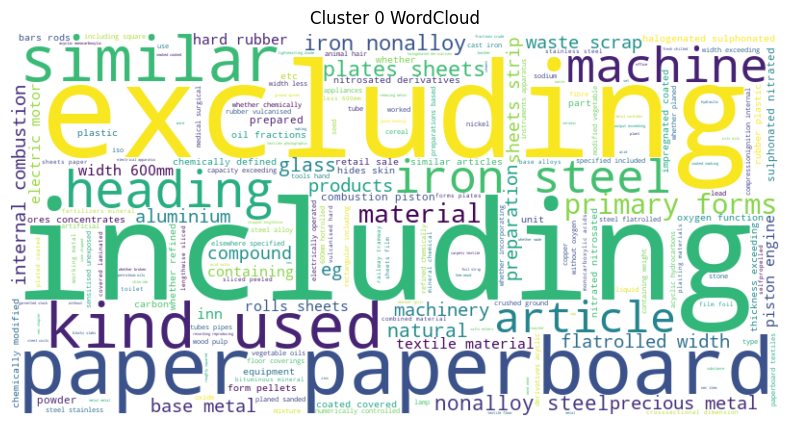

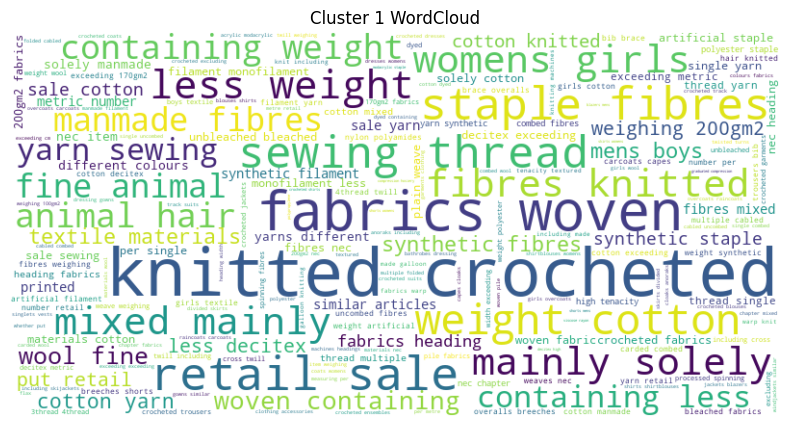

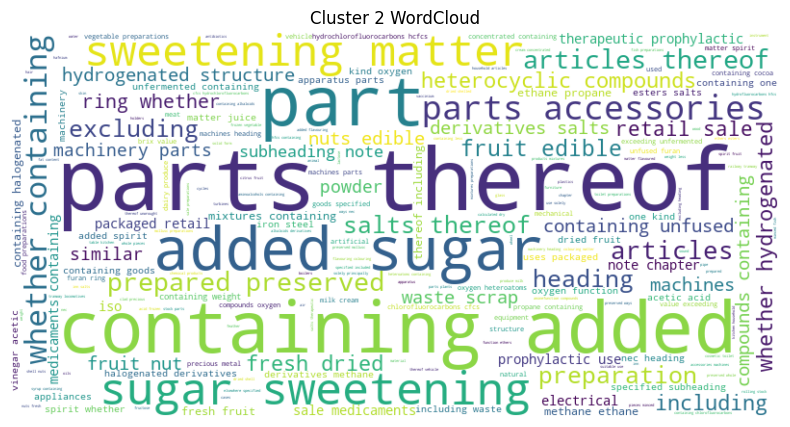

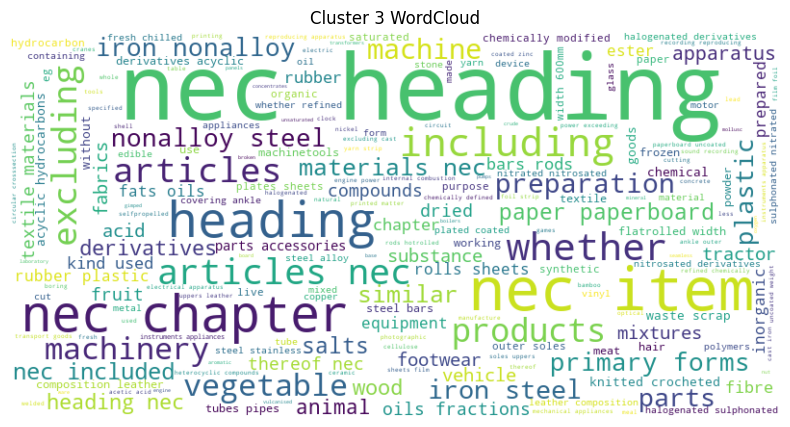

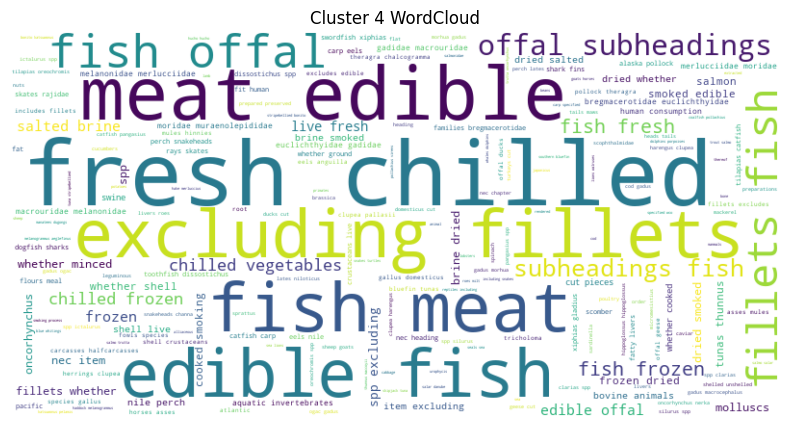

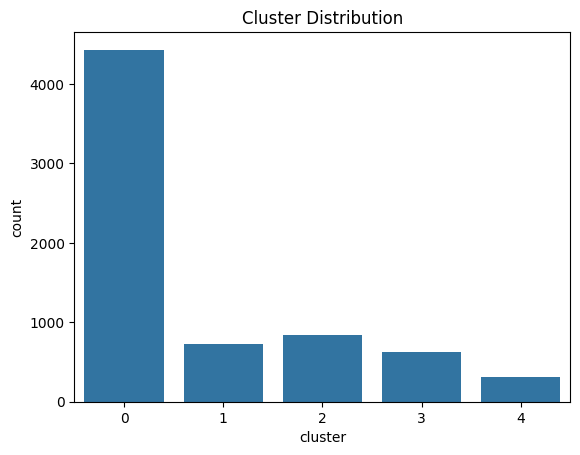

In [1]:
# Jupyter Notebook: Harmonized System Analysis with K-Means & NLP

# 1️⃣ Import Libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Optional NLP preprocessing
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

# 2️⃣ Load Dataset
df = pd.read_csv('harmonized-system.csv')

# Display first rows
df.head()

# 3️⃣ Explore Dataset
print(df.info())
print(df.describe())
print(df['description'].head())  # assuming there's a 'description' column

# 4️⃣ NLP Preprocessing on 'description'
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

df['clean_desc'] = df['description'].apply(clean_text)

# 5️⃣ Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df['clean_desc'])

# 6️⃣ Optional: scale numeric columns (if any)
# numeric_features = df[['weight', 'value']]  # example numeric columns
# scaler = StandardScaler()
# X_numeric = scaler.fit_transform(numeric_features)

# Combine text features and numeric features if needed
# from scipy.sparse import hstack
# X = hstack([X_text, X_numeric])

X = X_text  # using only text features for now

# 7️⃣ Apply K-Means Clustering
num_clusters = 5  # choose appropriate number
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

df['cluster'] = labels

# 8️⃣ Explore Cluster Results
for i in range(num_clusters):
    print(f"Cluster {i} descriptions:")
    print(df[df['cluster']==i]['description'].head(5), "\n")

# 9️⃣ Visualize clusters with WordCloud
for i in range(num_clusters):
    text = " ".join(df[df['cluster']==i]['clean_desc'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {i} WordCloud')
    plt.show()

# 10️⃣ Optional: Cluster distribution
sns.countplot(x='cluster', data=df)
plt.title('Cluster Distribution')
plt.show()